# 3 - Google Stock Price Forecasting - Time Series

<img src='https://cdn.litemarkets.com/cache/uploads/blog_post/Google-stock-forecast/google-stock-forecast.jpg?q=75&w=1000&s=bdfc12c56456c1923ea40dff8707f770'>

Bu çalışmada Google hisse senedi verileri üzerinden LSTM tabanlı bir deep learning modeli ile gelecekteki fiyatları tahmin edeceğiz.

## Akış

1. Veriyi yükleme
2. Veriyi okuma ve inceleme
3. Veri temizleme
4. Feature engineering
5. Veriyi ölçekleme ve sequence oluşturma
6. LSTM modeli kurma
7. Tahmin
8. Sonuç


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout


## 1. Veriyi Yükleme

In [2]:
from google.colab import drive
import os
import zipfile

drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/Colab Data Dosyaları/Google Stock Price Dataset.zip'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content')

os.listdir('/content')[:20]


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


['.config',
 'GoogleStockPriceTest.csv',
 'drive',
 'GoogleStockPrice_Train.csv',
 'sample_data']

## 2. Veriyi Okuma ve İnceleme

In [3]:
# Train ve test dosyalarını okuyup veri setlerinin yapısını inceleyeceğim.

In [4]:
train_df = pd.read_csv('/content/GoogleStockPrice_Train.csv')
test_df = pd.read_csv('/content/GoogleStockPriceTest.csv')

train_df.head()


,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [5]:
test_df.head()


,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [6]:
train_df.shape, test_df.shape


((1258, 6), (20, 6))

## 3. Veri Temizleme

In [7]:
# Bu bölümde tahmin için kullanacağım Open fiyat sütununu seçip sayısal dizi haline getireceğim.

In [8]:
train_set = train_df.iloc[:, 1:2].values
test_set = test_df.iloc[:, 1:2].values

train_set[:5]


array([[325.25],
       [331.27],
       [329.83],
       [328.34],
       [322.04]])

## 4. Feature Engineering

In [9]:
# Bu bölümde veriyi ölçekleyip LSTM için geçmiş zaman pencereleri oluşturacağım.

In [10]:
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(train_set)

x_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    x_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)

x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

x_train.shape, y_train.shape


((1198, 60, 1), (1198,))

## 5. Veriyi Ölçekleme ve Sequence Oluşturma

In [11]:
# Bu bölümde test verisi için de aynı pencere mantığını kullanarak giriş dizilerini hazırlayacağım.

In [12]:
dataset_total = pd.concat((train_df['Open'], test_df['Open']), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_df) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

x_test = []
for i in range(60, 60 + len(test_df)):
    x_test.append(inputs[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

x_test.shape


(20, 60, 1)

## 6. LSTM Modeli Kurma

In [13]:
# Bu bölümde LSTM tabanlı deep learning modelini kurup eğitim verisi ile eğiteceğim.

In [14]:
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))

model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=100, batch_size=32)


Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - loss: 0.0468
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - loss: 0.0069
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0062
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0055
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - loss: 0.0056
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - loss: 0.0048
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - loss: 0.0049
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0050
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - loss: 0.0050
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0046
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - loss: 0.0044
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - loss: 0.0044
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - loss: 0.0038
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.0040
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - loss: 0.0038
E

## 7. Tahmin

In [15]:
# Bu bölümde test verisi için tahmin alıp gerçek değerlerle karşılaştıracağım.

In [16]:
predicted_stock_price = model.predict(x_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)
predicted_stock_price[:5]


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step


array([[788.8097 ],
       [786.2928 ],
       [785.92065],
       [786.75244],
       [789.55194]], dtype=float32)

In [17]:
mae = mean_absolute_error(test_set, predicted_stock_price)
rmse = np.sqrt(mean_squared_error(test_set, predicted_stock_price))
print('MAE:', round(mae, 2))
print('RMSE:', round(rmse, 2))


MAE: 9.36
RMSE: 12.59


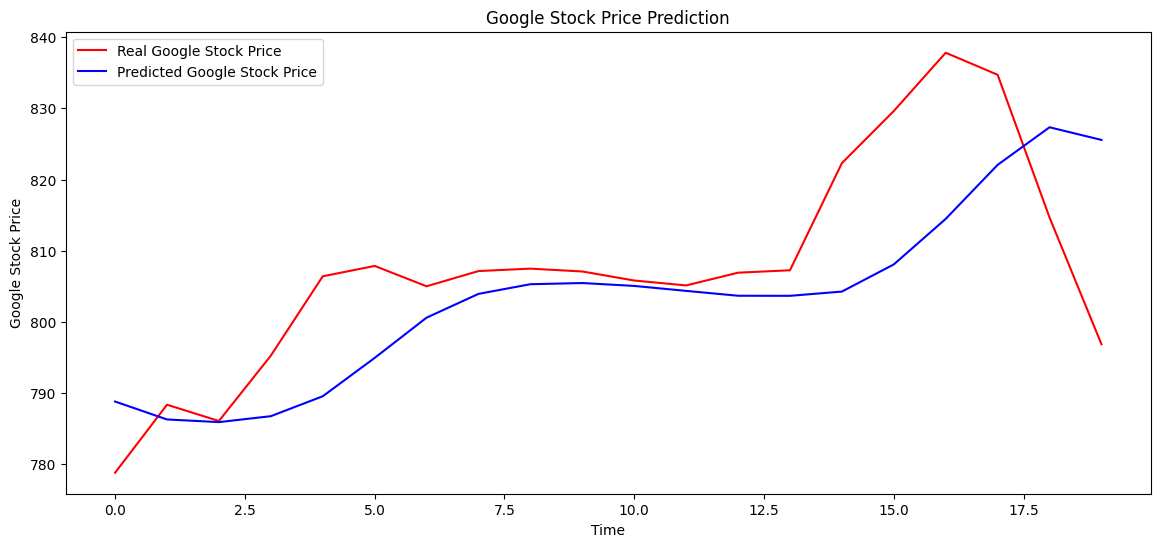

In [18]:
plt.figure(figsize=(14,6))
plt.plot(test_set, color='red', label='Real Google Stock Price')
plt.plot(predicted_stock_price, color='blue', label='Predicted Google Stock Price')
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()


## 8. Sonuç

Bu projede Google hisse senedi tahmini için LSTM tabanlı bir deep learning time series modeli kullanıldı. Elde edilen sonuçlara göre model test dönemi için gelecek fiyat değerlerini tahmin etti ve 9.36 MAE ile 12.59 RMSE değeri elde etti.
